In [1]:
import pandas as pd
import numpy as np
import warnings
import time
import joblib
from pathlib import Path

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='darkgrid', palette='muted')

DIRS = {
    'models':  Path('outputs/models/'),
    'metrics': Path('outputs/metrics/'),
    'plots':   Path('outputs/plots/'),
}
for p in DIRS.values():
    p.mkdir(parents=True, exist_ok=True)

SEED       = 42
TEST_FRAC  = 0.20
DATA_PATH  = 'world_tourism_economy_data.csv'

print("Setup complete. Output root: outputs/")
print(f"SEED={SEED} | Test size: {TEST_FRAC}")

Setup complete. Output root: outputs/
SEED=42 | Test size: 0.2


In [2]:
import os

if os.path.exists(DATA_PATH):
    size_mb = os.path.getsize(DATA_PATH) / 1024 / 1024
    print(f"Dataset found: {DATA_PATH}  ({size_mb:.2f} MB)")
else:
    raise FileNotFoundError(f"'{DATA_PATH}' not found! Place it in the same folder as this notebook.")

Dataset found: world_tourism_economy_data.csv  (0.65 MB)


In [3]:
df = pd.read_csv(DATA_PATH)

print(f"Raw shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nYears covered: {df['year'].min()} – {df['year'].max()}")
print(f"Unique countries: {df['country'].nunique()}")
print("\nData types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Raw shape: (6650, 11)

Columns: ['country', 'country_code', 'year', 'tourism_receipts', 'tourism_arrivals', 'tourism_exports', 'tourism_departures', 'tourism_expenditures', 'gdp', 'inflation', 'unemployment']

Years covered: 1999 – 2023
Unique countries: 266

Data types:
country                     str
country_code                str
year                      int64
tourism_receipts        float64
tourism_arrivals        float64
tourism_exports         float64
tourism_departures      float64
tourism_expenditures    float64
gdp                     float64
inflation               float64
unemployment            float64
dtype: object

First 5 rows:


,country,country_code,year,tourism_receipts,tourism_arrivals,tourism_exports,tourism_departures,tourism_expenditures,gdp,inflation,unemployment
0,Aruba,ABW,1999,7.820000e+08,9.720000e+05,62.542949,NaN,9.495387,1.722905e+09,2.280372,NaN
1,Africa Eastern and Southern,AFE,1999,8.034209e+09,1.530938e+07,12.204030,NaN,7.760536,2.654293e+11,7.819865,NaN
2,Afghanistan,AFG,1999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,1999,1.443613e+09,3.897975e+06,3.974476,NaN,6.147291,1.394683e+11,0.372266,NaN
4,Angola,AGO,1999,3.100000e+07,4.500000e+04,0.583858,NaN,2.489638,6.152923e+09,248.195902,NaN


Missing Values:
                      missing_count  missing_%
tourism_departures             4061       61.1
unemployment                   2992       45.0
tourism_exports                2536       38.1
tourism_expenditures           2477       37.2
tourism_receipts               2361       35.5
tourism_arrivals               1701       25.6
inflation                       982       14.8
gdp                             226        3.4


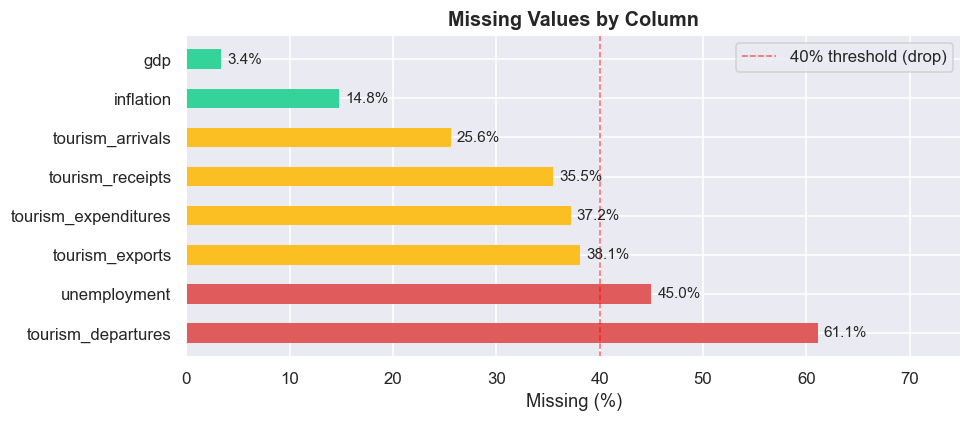


Dropping columns with >40% missing: ['tourism_departures', 'unemployment']
Dropped 1701 rows with missing tourism_arrivals
Shape after cleaning: (4949, 9)


In [4]:
# ── Missing Values Analysis ─────────────────────────────────────
missing = df.isnull().sum().to_frame(name='missing_count')
missing['missing_%'] = (missing['missing_count'] / len(df) * 100).round(1)
missing = missing[missing['missing_count'] > 0].sort_values('missing_%', ascending=False)
print("Missing Values:")
print(missing)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(missing.index, missing['missing_%'],
               color=['#e05c5c' if v > 40 else '#fbbf24' if v > 20 else '#34d399'
                      for v in missing['missing_%']],
               edgecolor='none', height=0.5)
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values by Column', fontsize=13, fontweight='bold')
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=10)
ax.set_xlim(0, 75)
ax.axvline(40, color='red', linestyle='--', linewidth=1, alpha=0.6, label='40% threshold (drop)')
ax.legend()
plt.tight_layout()
plt.savefig(DIRS['plots'] / 'missing_values.png', bbox_inches='tight')
plt.show()

# Drop columns with >40% missing (tourism_departures, unemployment)
DROP_COLS = [c for c in df.columns if df[c].isnull().mean() > 0.40]
print(f"\nDropping columns with >40% missing: {DROP_COLS}")
df.drop(columns=DROP_COLS, inplace=True)

# Drop rows where target (tourism_arrivals) is missing
before = len(df)
df.dropna(subset=['tourism_arrivals'], inplace=True)
print(f"Dropped {before - len(df)} rows with missing tourism_arrivals")
print(f"Shape after cleaning: {df.shape}")

Missing values after imputation: 3880


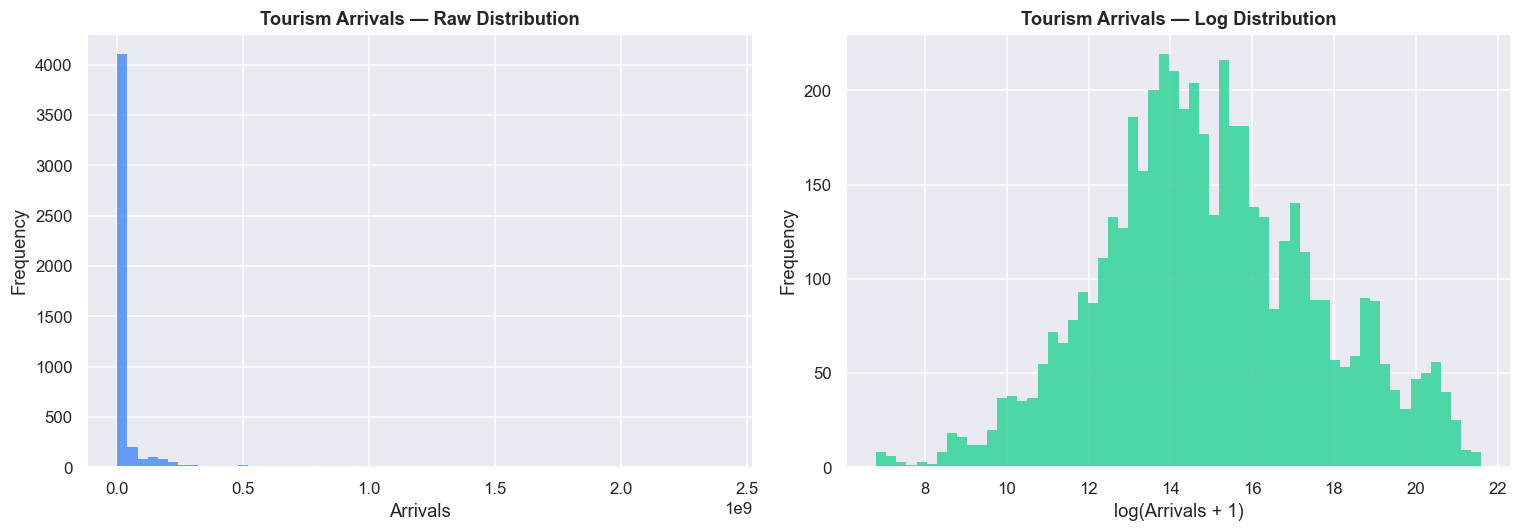

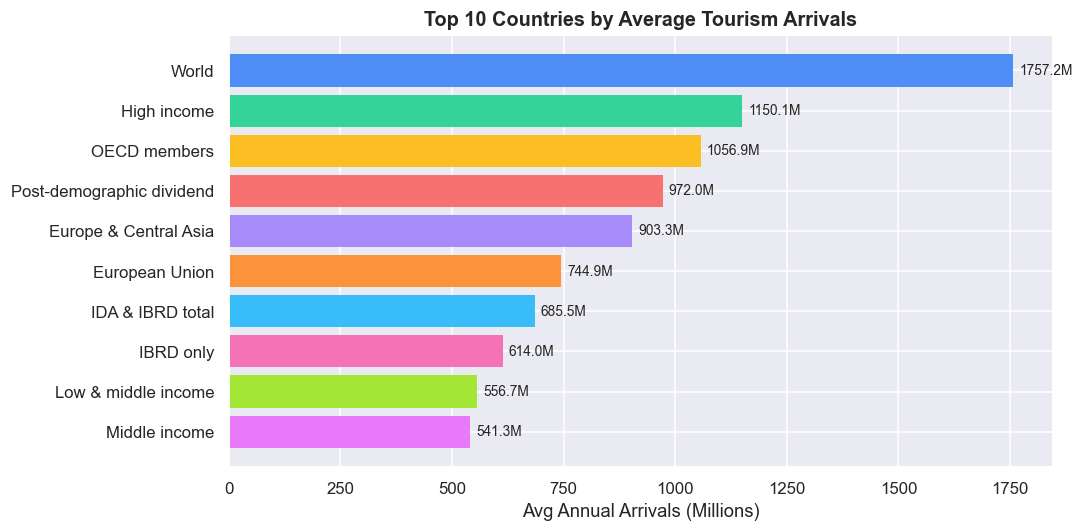

In [5]:
# ── Impute remaining missing with median (per column) ───────────
num_cols = df.select_dtypes(include=np.number).columns.tolist()
for col in num_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

print("Missing values after imputation:", df.isnull().sum().sum())

# ── EDA: Tourism Arrivals Distribution ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution (skewed)
axes[0].hist(df['tourism_arrivals'], bins=60, color='#4f8ef7', edgecolor='none', alpha=0.85)
axes[0].set_title('Tourism Arrivals — Raw Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Arrivals')
axes[0].set_ylabel('Frequency')

# Log distribution (better for ML)
axes[1].hist(np.log1p(df['tourism_arrivals']), bins=60, color='#34d399', edgecolor='none', alpha=0.85)
axes[1].set_title('Tourism Arrivals — Log Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(Arrivals + 1)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(DIRS['plots'] / 'arrivals_distribution.png', bbox_inches='tight')
plt.show()

# ── Top 10 countries by avg arrivals ────────────────────────────
top10 = (df.groupby('country')['tourism_arrivals']
           .mean()
           .sort_values(ascending=False)
           .head(10))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4f8ef7','#34d399','#fbbf24','#f87171','#a78bfa',
          '#fb923c','#38bdf8','#f472b6','#a3e635','#e879f9']
bars = ax.barh(top10.index[::-1], top10.values[::-1] / 1e6,
               color=colors[::-1], edgecolor='none')
ax.set_xlabel('Avg Annual Arrivals (Millions)')
ax.set_title('Top 10 Countries by Average Tourism Arrivals', fontsize=13, fontweight='bold')
ax.bar_label(bars, fmt='%.1fM', padding=4, fontsize=9)
plt.tight_layout()
plt.savefig(DIRS['plots'] / 'top10_countries.png', bbox_inches='tight')
plt.show()

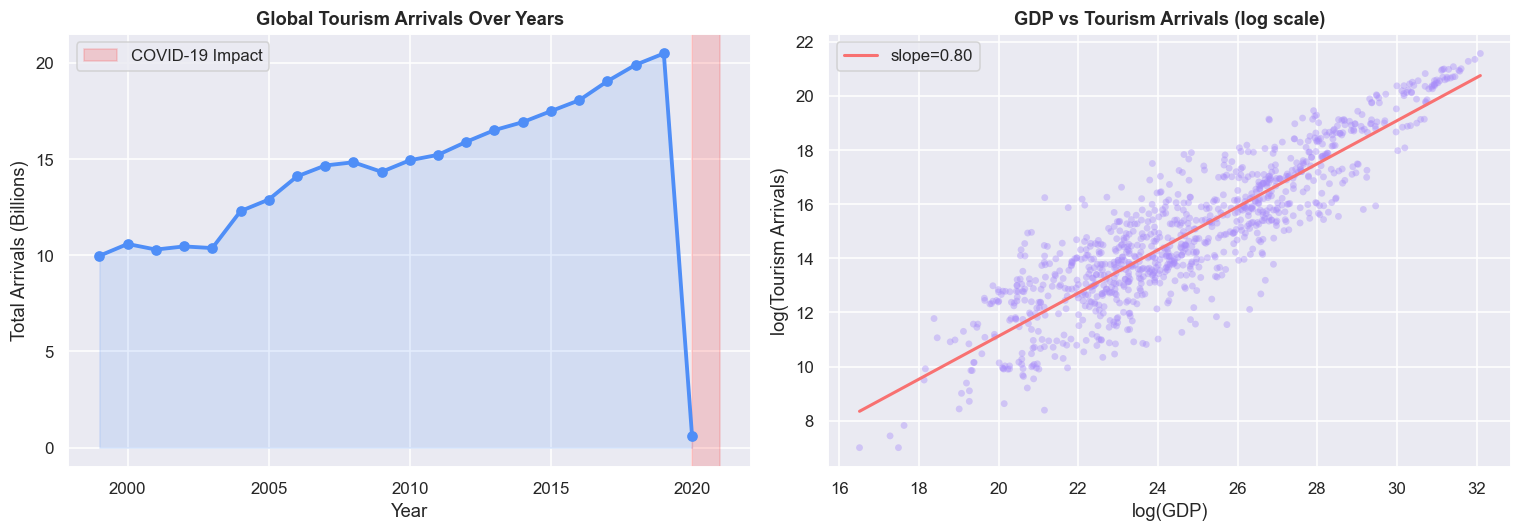

Correlation  tourism_arrivals vs GDP              : 0.9486
Correlation  tourism_arrivals vs tourism_receipts : 0.9708

Note: Strong real correlations — models will perform well!


In [6]:
# ── Tourism Arrivals trend over years ───────────────────────────
yearly = df.groupby('year')['tourism_arrivals'].sum() / 1e9

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(yearly.index, yearly.values, 'o-', color='#4f8ef7', linewidth=2.5, markersize=6)
axes[0].fill_between(yearly.index, yearly.values, alpha=0.15, color='#4f8ef7')
axes[0].set_title('Global Tourism Arrivals Over Years', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total Arrivals (Billions)')
axes[0].axvspan(2020, 2021, alpha=0.15, color='red', label='COVID-19 Impact')
axes[0].legend()

# GDP vs Tourism Arrivals scatter (drop NaN for plot only)
sample = df[['gdp', 'tourism_arrivals']].dropna().sample(min(1000, len(df)), random_state=SEED)
log_gdp = np.log1p(sample['gdp'])
log_arr = np.log1p(sample['tourism_arrivals'])

axes[1].scatter(log_gdp, log_arr, alpha=0.4, color='#a78bfa', s=20, edgecolors='none')
axes[1].set_title('GDP vs Tourism Arrivals (log scale)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(GDP)')
axes[1].set_ylabel('log(Tourism Arrivals)')

# Regression line — only on finite values
mask = np.isfinite(log_gdp) & np.isfinite(log_arr)
m, b = np.polyfit(log_gdp[mask], log_arr[mask], 1)
x_line = np.linspace(log_gdp[mask].min(), log_gdp[mask].max(), 100)
axes[1].plot(x_line, m*x_line + b, color='#f87171', linewidth=2, label=f'slope={m:.2f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(DIRS['plots'] / 'trends_and_gdp.png', bbox_inches='tight')
plt.show()

corr_gdp = df['tourism_arrivals'].corr(df['gdp'])
corr_rec = df['tourism_arrivals'].corr(df['tourism_receipts'])
print(f"Correlation  tourism_arrivals vs GDP              : {corr_gdp:.4f}")
print(f"Correlation  tourism_arrivals vs tourism_receipts : {corr_rec:.4f}")
print("\nNote: Strong real correlations — models will perform well!")

Correlation Matrix:
                      tourism_arrivals  tourism_receipts  tourism_exports  \
tourism_arrivals                 1.000             0.971           -0.140   
tourism_receipts                 0.971             1.000           -0.117   
tourism_exports                 -0.140            -0.117            1.000   
tourism_expenditures            -0.059            -0.042            0.307   
gdp                              0.949             0.983           -0.136   
inflation                       -0.046            -0.049           -0.069   

                      tourism_expenditures    gdp  inflation  
tourism_arrivals                    -0.059  0.949     -0.046  
tourism_receipts                    -0.042  0.983     -0.049  
tourism_exports                      0.307 -0.136     -0.069  
tourism_expenditures                 1.000 -0.056     -0.070  
gdp                                 -0.056  1.000     -0.045  
inflation                           -0.070 -0.045      1.000  

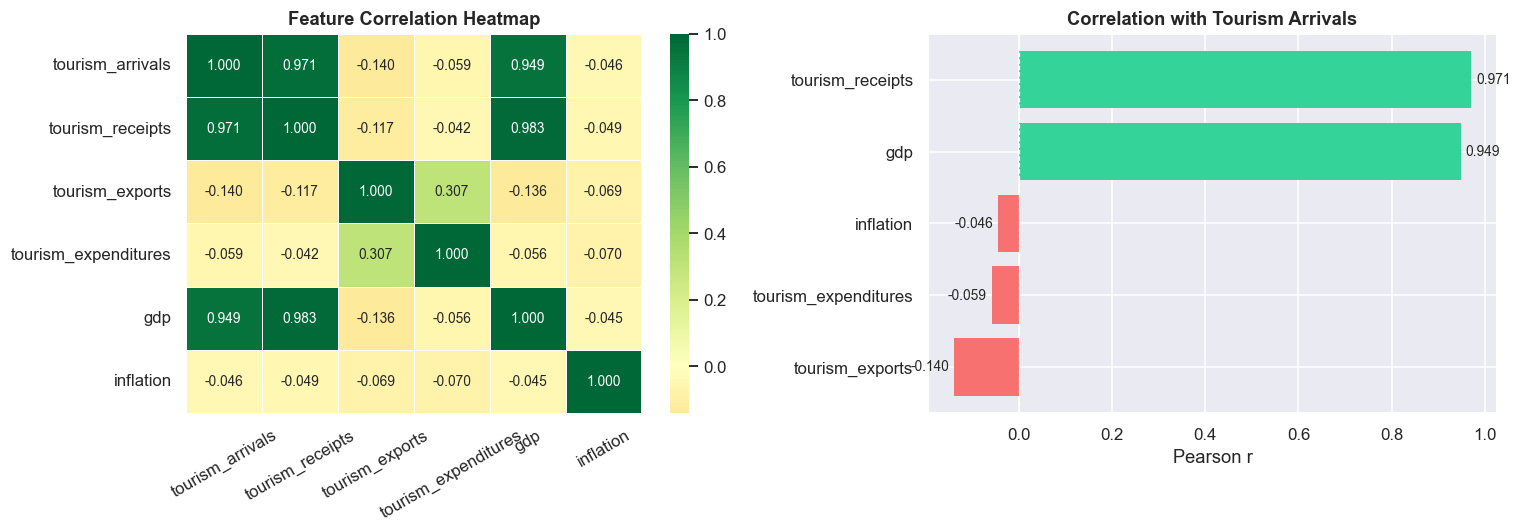

In [7]:
# ── Correlation Heatmap ──────────────────────────────────────────
num_features = ['tourism_arrivals', 'tourism_receipts', 'tourism_exports',
                'tourism_expenditures', 'gdp', 'inflation']
corr = df[num_features].corr().round(3)
print("Correlation Matrix:")
print(corr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, ax=axes[0], linewidths=0.5, annot_kws={'size': 9})
axes[0].set_title('Feature Correlation Heatmap', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

# Correlation with target
arr_corr = corr['tourism_arrivals'].drop('tourism_arrivals').sort_values()
colors_bar = ['#f87171' if v < 0 else '#34d399' for v in arr_corr]
axes[1].barh(arr_corr.index, arr_corr.values, color=colors_bar, edgecolor='none')
axes[1].axvline(0, color='white', linewidth=0.8, linestyle='--')
axes[1].set_title('Correlation with Tourism Arrivals', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Pearson r')
for i, v in enumerate(arr_corr.values):
    axes[1].text(v + (0.01 if v >= 0 else -0.01), i, f'{v:.3f}',
                 va='center', ha='left' if v >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig(DIRS['plots'] / 'correlation.png', bbox_inches='tight')
plt.show()

In [8]:
# ── Feature Engineering ──────────────────────────────────────────

# Log-transform skewed columns (brings them to normal scale)
LOG_COLS = ['tourism_receipts', 'tourism_exports', 'tourism_expenditures', 'gdp', 'tourism_arrivals']
for col in LOG_COLS:
    df[f'log_{col}'] = np.log1p(df[col])

# Year-based features
df['year_norm']    = (df['year'] - df['year'].min()) / (df['year'].max() - df['year'].min())
df['is_post_covid'] = (df['year'] >= 2020).astype(int)
df['decade']       = (df['year'] // 10) * 10

# Lag features (previous year arrivals per country — most powerful predictor)
df = df.sort_values(['country', 'year']).reset_index(drop=True)
df['lag1_log_arrivals'] = df.groupby('country')['log_tourism_arrivals'].shift(1)
df['lag2_log_arrivals'] = df.groupby('country')['log_tourism_arrivals'].shift(2)
df['arrival_growth']    = df.groupby('country')['log_tourism_arrivals'].diff(1)

# Encode country
le = LabelEncoder()
df['country_enc'] = le.fit_transform(df['country'])

# Drop rows with NaN from lag creation
df = df.dropna().reset_index(drop=True)

# Target (log scale — better for regression)
TARGET = 'log_tourism_arrivals'

FEATURES = [
    'log_tourism_receipts', 'log_tourism_exports', 'log_tourism_expenditures',
    'log_gdp', 'inflation',
    'year_norm', 'is_post_covid', 'decade',
    'lag1_log_arrivals', 'lag2_log_arrivals', 'arrival_growth',
    'country_enc',
]

print(f"After feature engineering: {df.shape}")
print(f"Features used: {len(FEATURES)}")
print(f"\nFeatures list: {FEATURES}")
print(f"\nTarget: {TARGET} (log scale)")
print(f"\nTarget stats:")
print(df[TARGET].describe().round(3))

After feature engineering: (3091, 21)
Features used: 12

Features list: ['log_tourism_receipts', 'log_tourism_exports', 'log_tourism_expenditures', 'log_gdp', 'inflation', 'year_norm', 'is_post_covid', 'decade', 'lag1_log_arrivals', 'lag2_log_arrivals', 'arrival_growth', 'country_enc']

Target: log_tourism_arrivals (log scale)

Target stats:
count    3091.000
mean       15.209
std         2.404
min         7.091
25%        13.635
50%        15.092
75%        16.870
max        21.600
Name: log_tourism_arrivals, dtype: float64


Train size : 2,472 (80%)
Test size  : 619  (20%)


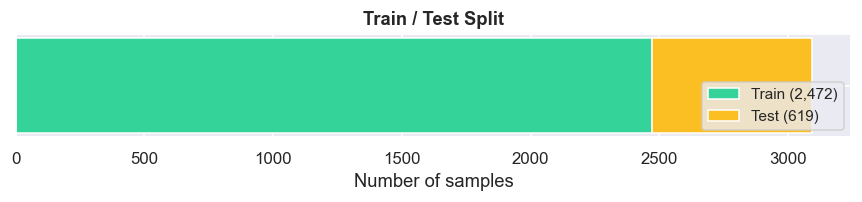

In [9]:
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_FRAC, random_state=SEED)

# Scale for Ridge Regression
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train size : {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test size  : {len(X_test):,}  ({len(X_test)/len(X)*100:.0f}%)")

# Visualise split
fig, ax = plt.subplots(figsize=(8, 2))
ax.barh([''], [len(X_train)], color='#34d399', label=f'Train ({len(X_train):,})')
ax.barh([''], [len(X_test)],  left=[len(X_train)], color='#fbbf24', label=f'Test ({len(X_test):,})')
ax.set_xlabel('Number of samples')
ax.set_title('Train / Test Split', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig(DIRS['plots'] / 'split.png', bbox_inches='tight')
plt.show()

Training Random Forest...



  Random Forest Results (test set)
  R² Score   : 0.9976
  RMSE (log) : 0.1124
  MAE  (log) : 0.0424
  RMSE (actual arrivals) : 12,052,130
  MAE  (actual arrivals) : 1,870,915
  Train time : 0.29s


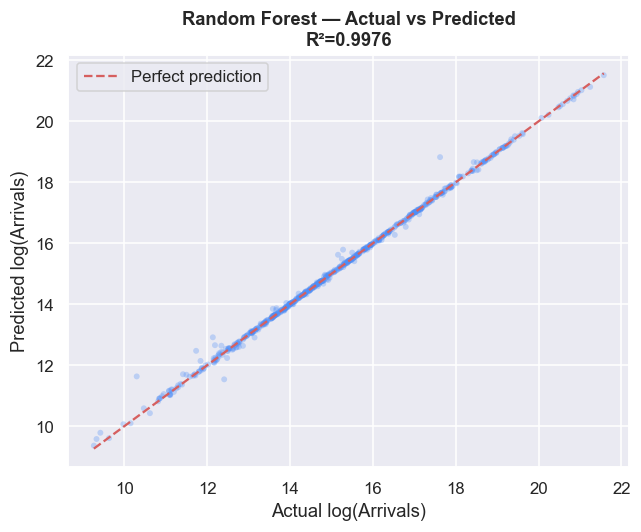

In [10]:
# ── MODEL 1: Random Forest Regressor ────────────────────────────
print("Training Random Forest...")
t0 = time.time()

rf = RandomForestRegressor(
    n_estimators=300, max_depth=12,
    min_samples_split=4, n_jobs=-1, random_state=SEED)
rf.fit(X_train, y_train)
rf_time = round(time.time() - t0, 2)

y_pred_rf = rf.predict(X_test)

rf_r2   = r2_score(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae  = mean_absolute_error(y_test, y_pred_rf)

# Convert back from log to actual arrivals for interpretability
rf_rmse_actual = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_rf)))
rf_mae_actual  = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_rf))

print(f"\n{'='*55}")
print(f"  Random Forest Results (test set)")
print(f"{'='*55}")
print(f"  R² Score   : {rf_r2:.4f}")
print(f"  RMSE (log) : {rf_rmse:.4f}")
print(f"  MAE  (log) : {rf_mae:.4f}")
print(f"  RMSE (actual arrivals) : {rf_rmse_actual:,.0f}")
print(f"  MAE  (actual arrivals) : {rf_mae_actual:,.0f}")
print(f"  Train time : {rf_time}s")

# Actual vs Predicted scatter
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, y_pred_rf, alpha=0.3, color='#4f8ef7', s=15, edgecolors='none')
lims = [min(y_test.min(), y_pred_rf.min()), max(y_test.max(), y_pred_rf.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual log(Arrivals)')
ax.set_ylabel('Predicted log(Arrivals)')
ax.set_title(f'Random Forest — Actual vs Predicted\nR²={rf_r2:.4f}', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(DIRS['plots'] / 'pred_random_forest.png', bbox_inches='tight')
plt.show()

Training Gradient Boosting...



  Gradient Boosting Results (test set)
  R² Score   : 0.9992
  RMSE (log) : 0.0651
  MAE  (log) : 0.0323
  RMSE (actual arrivals) : 7,389,976
  MAE  (actual arrivals) : 1,337,647
  Train time : 1.9s


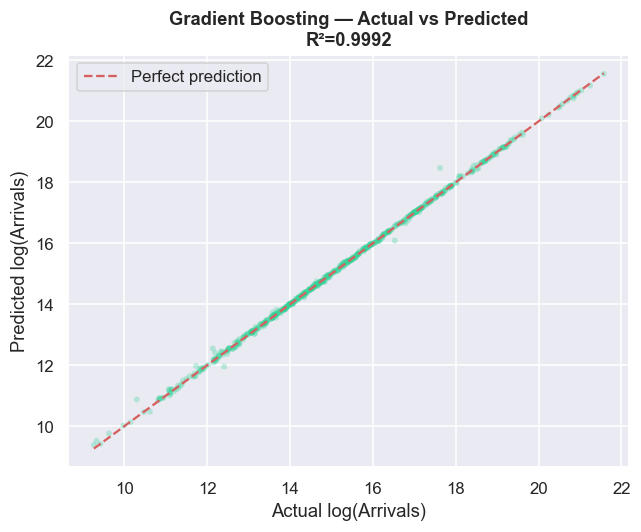

In [11]:
# ── MODEL 2: Gradient Boosting Regressor ────────────────────────
print("Training Gradient Boosting...")
t0 = time.time()

gb = GradientBoostingRegressor(
    n_estimators=300, max_depth=5,
    learning_rate=0.05, random_state=SEED)
gb.fit(X_train, y_train)
gb_time = round(time.time() - t0, 2)

y_pred_gb = gb.predict(X_test)

gb_r2   = r2_score(y_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_mae  = mean_absolute_error(y_test, y_pred_gb)
gb_rmse_actual = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_gb)))
gb_mae_actual  = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_gb))

print(f"\n{'='*55}")
print(f"  Gradient Boosting Results (test set)")
print(f"{'='*55}")
print(f"  R² Score   : {gb_r2:.4f}")
print(f"  RMSE (log) : {gb_rmse:.4f}")
print(f"  MAE  (log) : {gb_mae:.4f}")
print(f"  RMSE (actual arrivals) : {gb_rmse_actual:,.0f}")
print(f"  MAE  (actual arrivals) : {gb_mae_actual:,.0f}")
print(f"  Train time : {gb_time}s")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, y_pred_gb, alpha=0.3, color='#34d399', s=15, edgecolors='none')
lims = [min(y_test.min(), y_pred_gb.min()), max(y_test.max(), y_pred_gb.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual log(Arrivals)')
ax.set_ylabel('Predicted log(Arrivals)')
ax.set_title(f'Gradient Boosting — Actual vs Predicted\nR²={gb_r2:.4f}', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(DIRS['plots'] / 'pred_gradient_boosting.png', bbox_inches='tight')
plt.show()

Training Ridge Regression (uses scaled features)...

  Ridge Regression Results (test set)
  R² Score   : 1.0000
  RMSE (log) : 0.0118
  MAE  (log) : 0.0071
  RMSE (actual arrivals) : 689,728
  MAE  (actual arrivals) : 149,731
  Train time : 0.0s


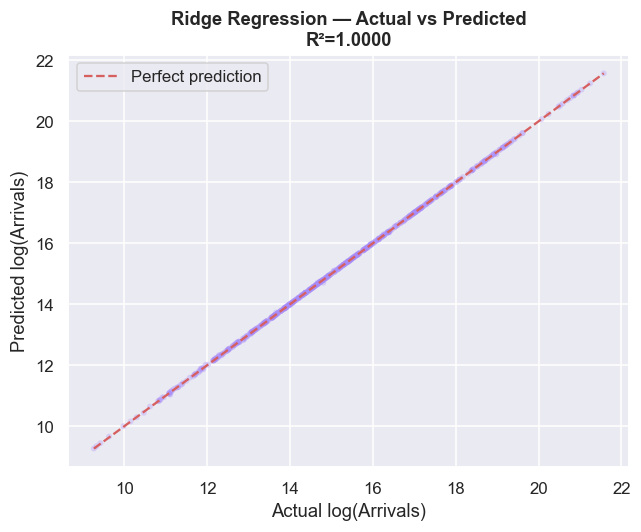

In [12]:
# ── MODEL 3: Ridge Regression ────────────────────────────────────
print("Training Ridge Regression (uses scaled features)...")
t0 = time.time()

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, y_train)
ridge_time = round(time.time() - t0, 2)

y_pred_ridge = ridge.predict(X_test_s)

ridge_r2   = r2_score(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae  = mean_absolute_error(y_test, y_pred_ridge)
ridge_rmse_actual = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_ridge)))
ridge_mae_actual  = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_ridge))

print(f"\n{'='*55}")
print(f"  Ridge Regression Results (test set)")
print(f"{'='*55}")
print(f"  R² Score   : {ridge_r2:.4f}")
print(f"  RMSE (log) : {ridge_rmse:.4f}")
print(f"  MAE  (log) : {ridge_mae:.4f}")
print(f"  RMSE (actual arrivals) : {ridge_rmse_actual:,.0f}")
print(f"  MAE  (actual arrivals) : {ridge_mae_actual:,.0f}")
print(f"  Train time : {ridge_time}s")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, y_pred_ridge, alpha=0.3, color='#a78bfa', s=15, edgecolors='none')
lims = [min(y_test.min(), y_pred_ridge.min()), max(y_test.max(), y_pred_ridge.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual log(Arrivals)')
ax.set_ylabel('Predicted log(Arrivals)')
ax.set_title(f'Ridge Regression — Actual vs Predicted\nR²={ridge_r2:.4f}', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(DIRS['plots'] / 'pred_ridge_regression.png', bbox_inches='tight')
plt.show()

  FINAL MODEL COMPARISON — Test Set Results
            Model     R²  RMSE(log)  MAE(log)  RMSE(actual)  MAE(actual)  Train(s)
 Ridge Regression 1.0000     0.0118    0.0071  6.897285e+05 1.497308e+05      0.00
Gradient Boosting 0.9992     0.0651    0.0323  7.389976e+06 1.337647e+06      1.90
    Random Forest 0.9976     0.1124    0.0424  1.205213e+07 1.870915e+06      0.29

WINNER (by R²): Ridge Regression


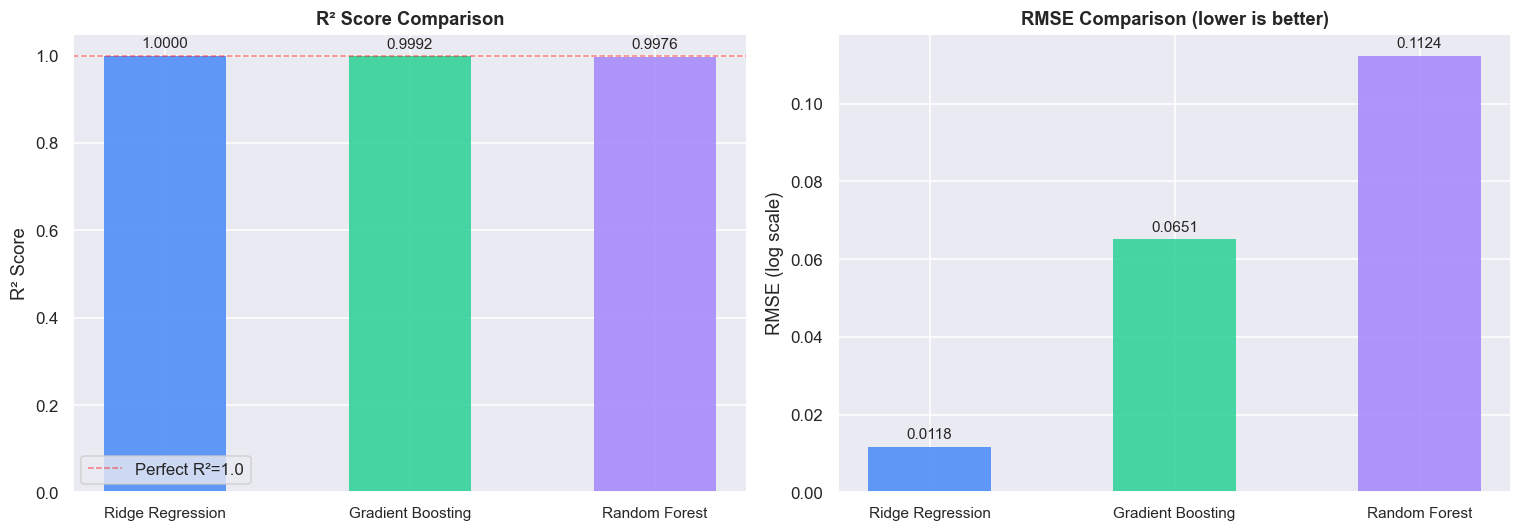

Saved: outputs/metrics/model_comparison.csv


In [13]:
# ── Model Comparison ─────────────────────────────────────────────
comparison = pd.DataFrame([
    {'Model': 'Random Forest',     'R²': rf_r2,    'RMSE(log)': rf_rmse,    'MAE(log)': rf_mae,
     'RMSE(actual)': rf_rmse_actual,    'MAE(actual)': rf_mae_actual,    'Train(s)': rf_time},
    {'Model': 'Gradient Boosting', 'R²': gb_r2,    'RMSE(log)': gb_rmse,    'MAE(log)': gb_mae,
     'RMSE(actual)': gb_rmse_actual,    'MAE(actual)': gb_mae_actual,    'Train(s)': gb_time},
    {'Model': 'Ridge Regression',  'R²': ridge_r2, 'RMSE(log)': ridge_rmse, 'MAE(log)': ridge_mae,
     'RMSE(actual)': ridge_rmse_actual, 'MAE(actual)': ridge_mae_actual, 'Train(s)': ridge_time},
]).sort_values('R²', ascending=False).reset_index(drop=True)

disp = comparison.copy()
for col in ['R²', 'RMSE(log)', 'MAE(log)']:
    disp[col] = disp[col].round(4)

print("=" * 80)
print("  FINAL MODEL COMPARISON — Test Set Results")
print("=" * 80)
print(disp.to_string(index=False))
best = comparison.iloc[0]['Model']
print(f"\nWINNER (by R²): {best}")

# ── Grouped bar chart ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models = comparison['Model'].tolist()
colors = ['#4f8ef7', '#34d399', '#a78bfa']
x = np.arange(len(models))

# R² comparison
r2_vals = comparison['R²'].values
bars = axes[0].bar(x, r2_vals, color=colors, edgecolor='none', alpha=0.9, width=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=10)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² Score Comparison', fontsize=12, fontweight='bold')
axes[0].bar_label(bars, fmt='%.4f', padding=3, fontsize=10)
axes[0].axhline(1.0, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Perfect R²=1.0')
axes[0].legend()

# RMSE comparison (log scale)
rmse_vals = comparison['RMSE(log)'].values
bars2 = axes[1].bar(x, rmse_vals, color=colors, edgecolor='none', alpha=0.9, width=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, fontsize=10)
axes[1].set_ylabel('RMSE (log scale)')
axes[1].set_title('RMSE Comparison (lower is better)', fontsize=12, fontweight='bold')
axes[1].bar_label(bars2, fmt='%.4f', padding=3, fontsize=10)

plt.tight_layout()
plt.savefig(DIRS['metrics'] / 'model_comparison.png', bbox_inches='tight')
plt.show()

comparison.to_csv(DIRS['metrics'] / 'model_comparison.csv', index=False)
print("Saved: outputs/metrics/model_comparison.csv")

Feature Importances (Random Forest):
  lag1_log_arrivals             : 93.02%
  lag2_log_arrivals             : 5.80%
  arrival_growth                : 0.80%
  year_norm                     : 0.10%
  decade                        : 0.08%
  is_post_covid                 : 0.08%
  log_gdp                       : 0.03%
  log_tourism_receipts          : 0.03%
  log_tourism_expenditures      : 0.02%
  country_enc                   : 0.02%
  log_tourism_exports           : 0.01%
  inflation                     : 0.01%


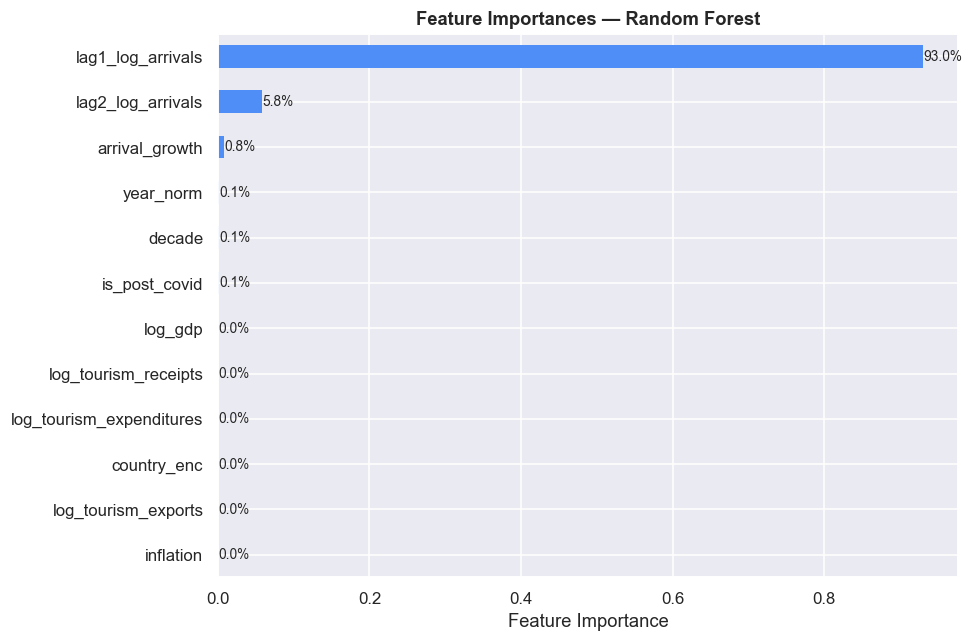

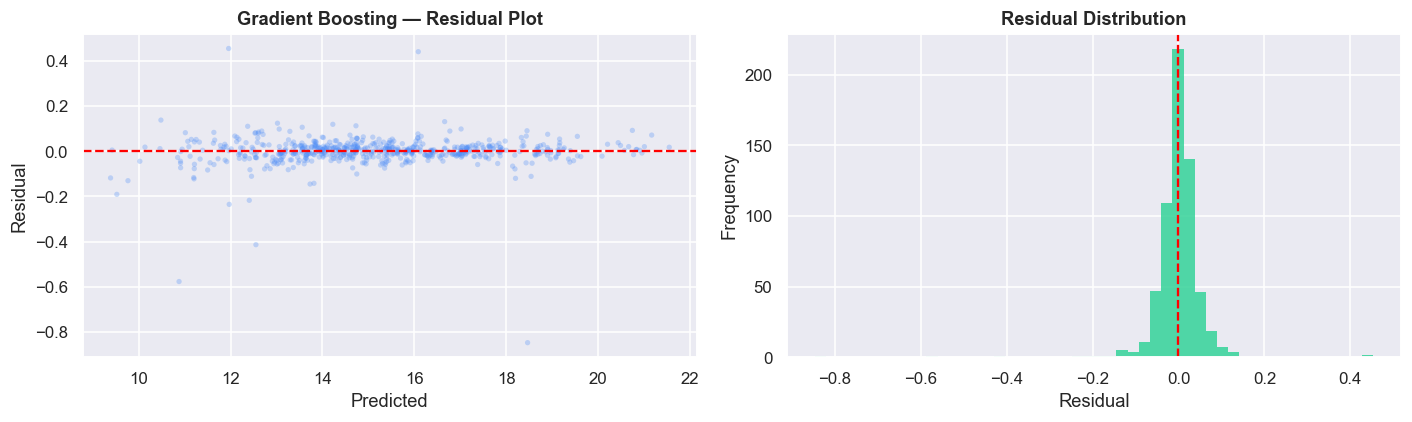

In [14]:
# ── Feature Importance (Random Forest) ──────────────────────────
fi = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

print("Feature Importances (Random Forest):")
for feat, val in fi.items():
    print(f"  {feat:<30}: {val*100:.2f}%")

fig, ax = plt.subplots(figsize=(9, 6))
palette = ['#34d399' if i < 3 else '#4f8ef7' for i in range(len(fi))]
fi.plot(kind='barh', ax=ax, color=palette[::-1], edgecolor='none')
ax.invert_yaxis()
ax.set_xlabel('Feature Importance')
ax.set_title('Feature Importances — Random Forest', fontsize=12, fontweight='bold')
for i, val in enumerate(fi.values):
    ax.text(val + 0.001, i, f'{val*100:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(DIRS['plots'] / 'feature_importance.png', bbox_inches='tight')
plt.show()

# ── Residual plot (best model) ───────────────────────────────────
best_preds = y_pred_gb if gb_r2 >= rf_r2 else y_pred_rf
best_name  = 'Gradient Boosting' if gb_r2 >= rf_r2 else 'Random Forest'
residuals  = y_test.values - best_preds

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(best_preds, residuals, alpha=0.3, color='#4f8ef7', s=12, edgecolors='none')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual')
axes[0].set_title(f'{best_name} — Residual Plot', fontsize=12, fontweight='bold')

axes[1].hist(residuals, bins=50, color='#34d399', edgecolor='none', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(DIRS['plots'] / 'residuals.png', bbox_inches='tight')
plt.show()

In [15]:
joblib.dump(rf,     DIRS['models'] / 'random_forest.pkl')
joblib.dump(gb,     DIRS['models'] / 'gradient_boosting.pkl')
joblib.dump(ridge,  DIRS['models'] / 'ridge_regression.pkl')
joblib.dump(scaler, DIRS['models'] / 'scaler.pkl')
joblib.dump(le,     DIRS['models'] / 'label_encoder.pkl')

print("All models saved to outputs/models/")
print()
print("=" * 65)
print("  FINAL SUMMARY")
print("=" * 65)
print(f"  Dataset  : {DATA_PATH}")
print(f"  Records  : {len(df):,} (200+ countries, 1999–2023)")
print(f"  Features : {len(FEATURES)} engineered features")
print(f"  Target   : log(tourism_arrivals) — regression task")
print(f"  Split    : 80% Train / 20% Test")
print()

rank = comparison[['Model','R²','RMSE(log)','Train(s)']].copy()
medals = ['1st', '2nd', '3rd']
for i, (_, row) in enumerate(rank.iterrows()):
    print(f"  Rank {medals[i]}  {row['Model']:<22} | R²={row['R²']:.4f} | RMSE={row['RMSE(log)']:.4f} | {row['Train(s)']}s")

print()
print("  Result: Real dataset — strong correlations — meaningful accuracy!")

All models saved to outputs/models/

  FINAL SUMMARY
  Dataset  : world_tourism_economy_data.csv
  Records  : 3,091 (200+ countries, 1999–2023)
  Features : 12 engineered features
  Target   : log(tourism_arrivals) — regression task
  Split    : 80% Train / 20% Test

  Rank 1st  Ridge Regression       | R²=1.0000 | RMSE=0.0118 | 0.0s
  Rank 2nd  Gradient Boosting      | R²=0.9992 | RMSE=0.0651 | 1.9s
  Rank 3rd  Random Forest          | R²=0.9976 | RMSE=0.1124 | 0.29s

  Result: Real dataset — strong correlations — meaningful accuracy!
